# HOMEWORK 4

For this homework you are going to implement a lane line detector. Lane line detection is crucial for ADAS (Advanced Driver Assistance Systems) systems and, in particular, for LKA (Lane Keep Assist). You will use a picture from a front facing camera (mounted on the car) and will implement the following steps:
* Convert image to gray scale
* Compute edge map
* Apply Hough transform to obtain line parametrizations

In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load and show the camera frame.

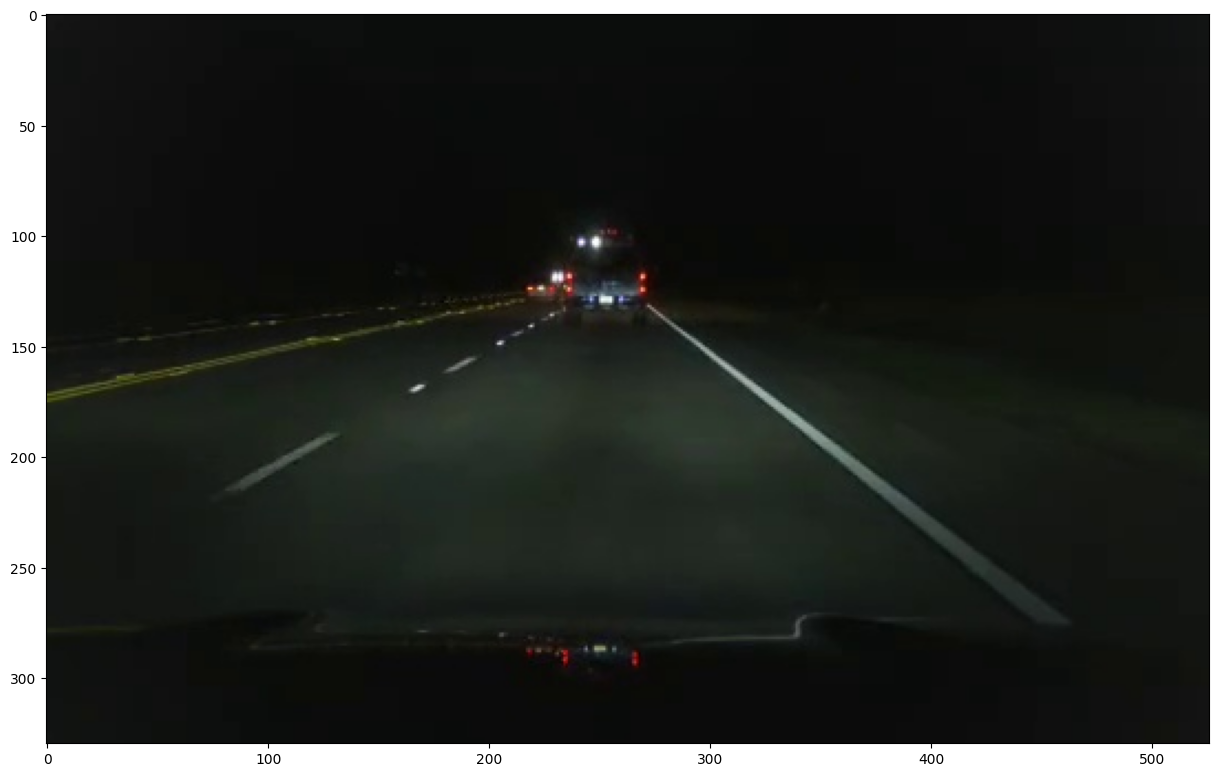

In [228]:
img = cv2.imread('data/dashcam.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [229]:
# Convert image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [308]:
# Obtain edge map
edges = cv2.Canny(gray, threshold1=100, threshold2=150)

(<Axes: title={'center': 'Edge map'}>, <matplotlib.image.AxesImage object at 0x7f62efacf890>, Text(0.5, 1.0, 'Edge map'))

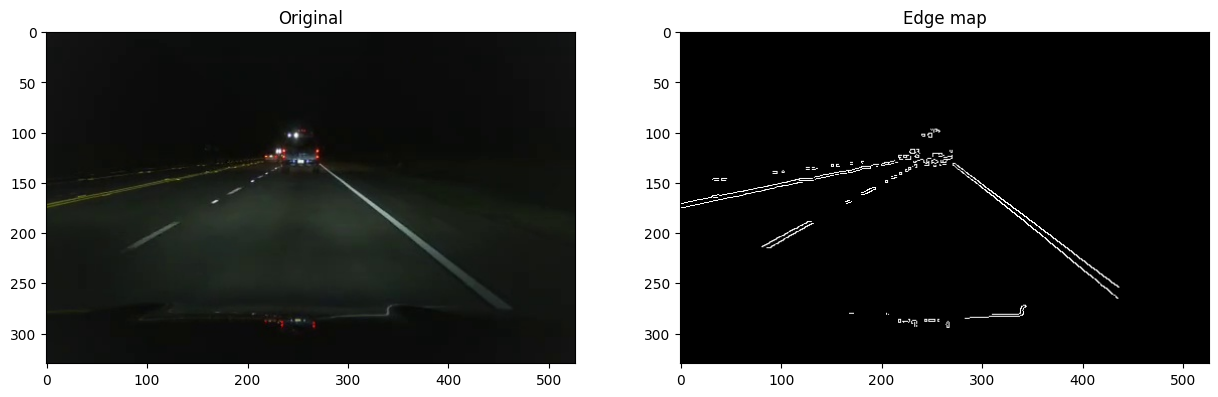

In [309]:
# Let's plot the images
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edge map')

In [310]:
# Apply Hough transform to parametrize the lines
lines = cv2.HoughLines(edges, rho=5, theta=3*np.pi/180, threshold=150)
# Let's get rid of the unnecessary dimension
lines = lines[:, 0, :]

(<Axes: title={'center': 'Hough lines'}>, <matplotlib.image.AxesImage object at 0x7f6315263ed0>, Text(0.5, 1.0, 'Hough lines'))

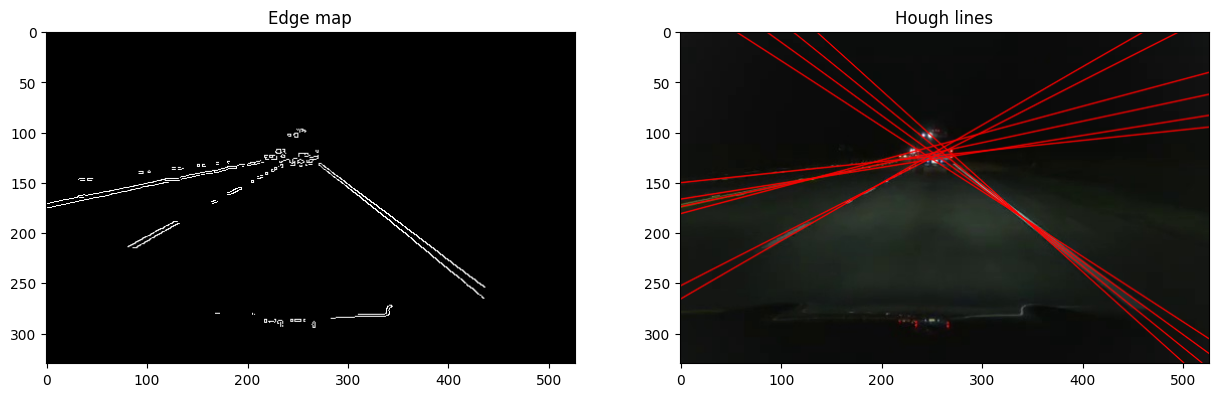

In [311]:
# Plot the resulting Hough lines
result = np.copy(img)
        
for line in lines:
    rho = line[0]
    theta = line[1]
    
    a = math.cos(theta)
    b = math.sin(theta)
    
    x0 = a * rho
    y0 = b * rho
    
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The edge map looks good but the Hough lines are too noisy. Let's clean the Hough lines first by removing all lines that we know cannot represent a lane line. In other words, all lines that are approximately horizontal shall be removed. Remember that horizontal lines correspond to theta = 90 degrees.

In [312]:
# Filter out all lines that are approximately horizontal (+/- 15 degrees). 
threshold = 15
filtered_lines = []
for line in lines:
    # Extract theta for current line (remember Hough works with radians)
    thetaDeg = line[1] / (np.pi/180)
    # Keep line if theta is not horizontal
    if 90 - threshold >= thetaDeg or thetaDeg >= 90 + threshold:
        filtered_lines.append(line)

(<Axes: title={'center': 'Hough lines'}>, <matplotlib.image.AxesImage object at 0x7f62fa997ed0>, Text(0.5, 1.0, 'Hough lines'))

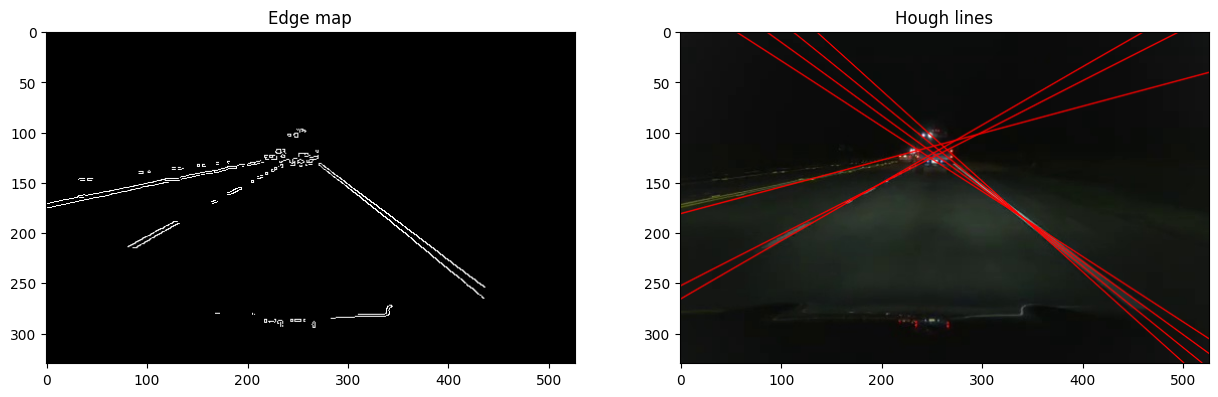

In [313]:
# Let's plot the resulting filtered lines
result = np.copy(img)
 
for line in filtered_lines:
    rho = line[0]
    theta = line[1]
    
    a = math.cos(theta)
    b = math.sin(theta)
    
    x0 = a * rho
    y0 = b * rho
    
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The result is now much better, but still we see some very similar lines. How can we get rid of them?
* Let's apply k-means clustering. It will find the clusters of the 3 lines and use the averages.

In [318]:
# We will apply k-means clustering to refine the detected lines.

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4).fit(filtered_lines)
kmeans.cluster_centers_

array([[-40.        ,   2.17293489],
       [227.5       ,   1.07337749],
       [-80.        ,   2.27765477],
       [175.        ,   1.30899692]])

(<Axes: title={'center': 'Hough lines'}>, <matplotlib.image.AxesImage object at 0x7f63009e5090>, Text(0.5, 1.0, 'Hough lines'))

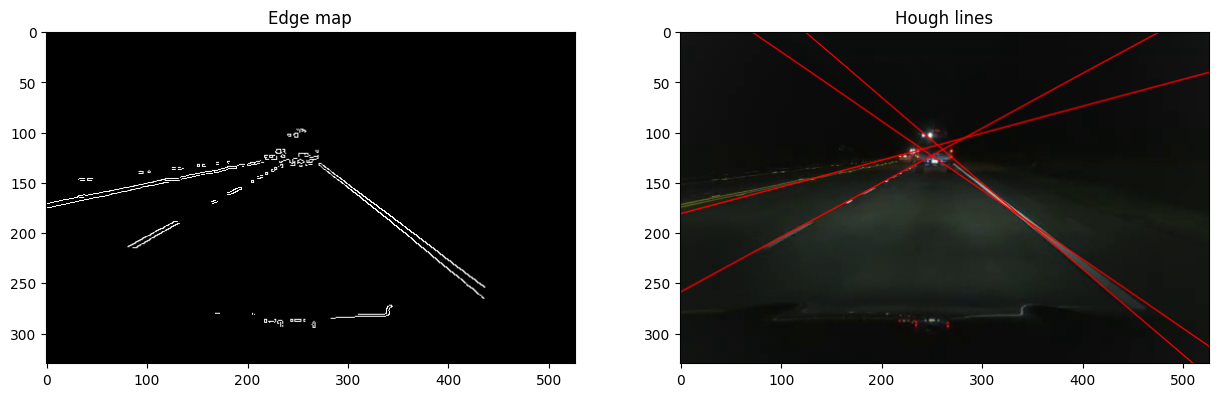

In [319]:
# Again, let's plot the resulting filtered lines
result = np.copy(img)
    
for line in kmeans.cluster_centers_:
    rho = line[0]
    theta = line[1]
    
    a = math.cos(theta)
    b = math.sin(theta)
    
    x0 = a * rho
    y0 = b * rho
    
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

### Questions
Do you see anything strange in the final result?

As I was experimenting with different images and manually playing with
coefficients, I did face some weird line predictions due to the noicy details
like buildings at the horizon, mirrored objects on the hood of the car etc. It
was tough to find balance of keeping the important features and reducing the
unnesseccary ones. The clusterization also seemed to cause troubles like
multiple resulting clusters in line group with many lines, and some alone lines
were not taken into account.

Do you think the Hough transform resolution is important for obtaining a good result? Why?

I feel those are crutial as lower offset resolution helps to focus on more
saturated features, and angle resolution can highlight the true lines on the
picture with more lines, happening to be then grouped by clusterizationg*

Do you think the Hough transform accumulator threshold is important for obtaining a good result? Why?

Of course it's also important, as the method itself relies on the number of line
intersections in Hough space, and the threshold helps to either only keep
features with more probability of being a real line, or making some room for
unobvious features.